**Install All Libraries**

In [29]:
!pip install nltk wordcloud scikit-learn xgboost imbalanced-learn textblob -q

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('vader_lexicon', quiet=True)

print("✅ All libraries ready!")

✅ All libraries ready!


**Import Libraries**

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re, string, warnings
warnings.filterwarnings('ignore')

from collections import Counter
from wordcloud import WordCloud

# NLP
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score, roc_auc_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import pickle

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

PALETTE = {
    'Normal'              : '#2ECC71',
    'Depression'          : '#3498DB',
    'Suicidal'            : '#E74C3C',
    'Anxiety'             : '#F39C12',
    'Bipolar'             : '#9B59B6',
    'Stress'              : '#E67E22',
    'Personality disorder': '#1ABC9C',
}
COLORS = list(PALETTE.values())
print("✅ Imports done!")

✅ Imports done!


**Load & Preview Dataset**

In [31]:
from google.colab import files
print("📂 Upload your  mental_health_combined.csv  file:")
uploaded = files.upload()

df = pd.read_csv('mental_health_combined.csv')
df = df.dropna(subset=['statement']).reset_index(drop=True)
df = df[['statement', 'status']].copy()
df.columns = ['text', 'label']

print("=" * 55)
print("  ✅  Dataset Loaded!")
print("=" * 55)
print(f"  Total Posts : {len(df):,}")
print(f"  Categories  : {df['label'].nunique()}")
print()
print("  Label Distribution:")
for label, count in df['label'].value_counts().items():
    bar = '█' * (count // 500)
    print(f"  {label:<25} {count:>6,}  {bar}")
print("=" * 55)
df.head(5)

📂 Upload your  mental_health_combined.csv  file:


Saving mental_health_combined.csv to mental_health_combined (1).csv
  ✅  Dataset Loaded!
  Total Posts : 52,681
  Categories  : 7

  Label Distribution:
  Normal                    16,343  ████████████████████████████████
  Depression                15,404  ██████████████████████████████
  Suicidal                  10,652  █████████████████████
  Anxiety                    3,841  ███████
  Bipolar                    2,777  █████
  Stress                     2,587  █████
  Personality disorder       1,077  ██


,text,label
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


 **Text Preprocessing**

In [32]:
STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()
sia         = SentimentIntensityAnalyzer()

# Mental health specific keywords for trigger detection
TRIGGER_KEYWORDS = {
    'suicidal_risk'   : ['suicide', 'kill myself', 'end my life', 'want to die',
                          'no reason to live', 'better off dead', 'self harm',
                          'cut myself', 'overdose', 'worthless', 'hopeless'],
    'depression_signs': ['empty', 'numb', 'pointless', 'exhausted', 'crying',
                          'isolate', 'no energy', 'sleep all day', 'worthless',
                          'no motivation', 'can\'t get up'],
    'anxiety_signs'   : ['panic attack', 'heart racing', 'can\'t breathe',
                          'overthinking', 'catastrophize', 'worry', 'dread',
                          'nervous', 'trembling', 'shaking'],
    'crisis_words'    : ['crisis', 'emergency', 'help me', 'please help',
                          'desperate', 'can\'t take it', 'breaking down'],
}

def clean_text(text):
    """Full NLP preprocessing pipeline"""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)        # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)              # remove mentions/hashtags
    text = re.sub(r'[^a-z\s]', ' ', text)              # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()            # clean whitespace
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

def get_sentiment_scores(text):
    """Get VADER sentiment + TextBlob polarity"""
    vader   = sia.polarity_scores(str(text))
    blob    = TextBlob(str(text))
    return {
        'vader_compound'  : vader['compound'],
        'vader_negative'  : vader['neg'],
        'vader_positive'  : vader['pos'],
        'vader_neutral'   : vader['neu'],
        'tb_polarity'     : blob.sentiment.polarity,
        'tb_subjectivity' : blob.sentiment.subjectivity,
    }

def compute_severity_score(text, label=None):
    """
    Compute a 0-100 mental health severity/risk score.
    Higher = more concerning.
    """
    text_lower = str(text).lower()
    score = 0

    # Base score from label
    label_base = {
        'Normal': 5, 'Stress': 25, 'Anxiety': 40,
        'Depression': 55, 'Bipolar': 60,
        'Personality disorder': 65, 'Suicidal': 85
    }
    if label:
        score += label_base.get(label, 30)

    # Keyword boosters
    for word in TRIGGER_KEYWORDS['suicidal_risk']:
        if word in text_lower:
            score += 5
    for word in TRIGGER_KEYWORDS['depression_signs']:
        if word in text_lower:
            score += 2
    for word in TRIGGER_KEYWORDS['crisis_words']:
        if word in text_lower:
            score += 3

    # Sentiment booster (very negative = higher risk)
    vader = sia.polarity_scores(text_lower)
    if vader['compound'] < -0.5:
        score += 10
    elif vader['compound'] < -0.2:
        score += 5

    return min(int(score), 100)

def detect_triggers(text):
    """Return which trigger categories are detected"""
    text_lower = str(text).lower()
    found = []
    for category, words in TRIGGER_KEYWORDS.items():
        if any(w in text_lower for w in words):
            found.append(category.replace('_', ' ').title())
    return found if found else ['None detected']

print("Preprocessing 52,000+ posts — please wait...")
df['clean_text']    = df['text'].apply(clean_text)
df['text_length']   = df['text'].apply(lambda x: len(str(x)))
df['word_count']    = df['text'].apply(lambda x: len(str(x).split()))
df['clean_length']  = df['clean_text'].apply(len)

# Sentiment features
print("Computing sentiment scores...")
sentiments          = df['text'].apply(get_sentiment_scores)
sentiment_df        = pd.DataFrame(sentiments.tolist())
df                  = pd.concat([df, sentiment_df], axis=1)

# Severity scores
print("Computing severity scores...")
df['severity_score'] = df.apply(
    lambda r: compute_severity_score(r['text'], r['label']), axis=1
)

print(f"✅ Preprocessing complete! Shape: {df.shape}")
df[['text', 'label', 'severity_score', 'vader_compound', 'tb_polarity']].head(8)


Preprocessing 52,000+ posts — please wait...
Computing sentiment scores...
Computing severity scores...
✅ Preprocessing complete! Shape: (52681, 13)


,text,label,severity_score,vader_compound,tb_polarity
0,oh my gosh,Anxiety,40,0.0000,0.0000
1,"trouble sleeping, confused mind, restless hear...",Anxiety,50,-0.7269,-0.3000
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,50,-0.7351,-0.2500
3,I've shifted my focus to something else but I'...,Anxiety,45,-0.4215,0.0000
4,"I'm restless and restless, it's been a month n...",Anxiety,45,-0.4939,-0.3125
5,"every break, you must be nervous, like somethi...",Anxiety,45,-0.2144,-0.5000
6,"I feel scared, anxious, what can I do? And may...",Anxiety,40,0.2500,0.1250
7,Have you ever felt nervous but didn't know why?,Anxiety,40,-0.1406,0.0000


**EDA CHART 1: Distribution & Class Overview**

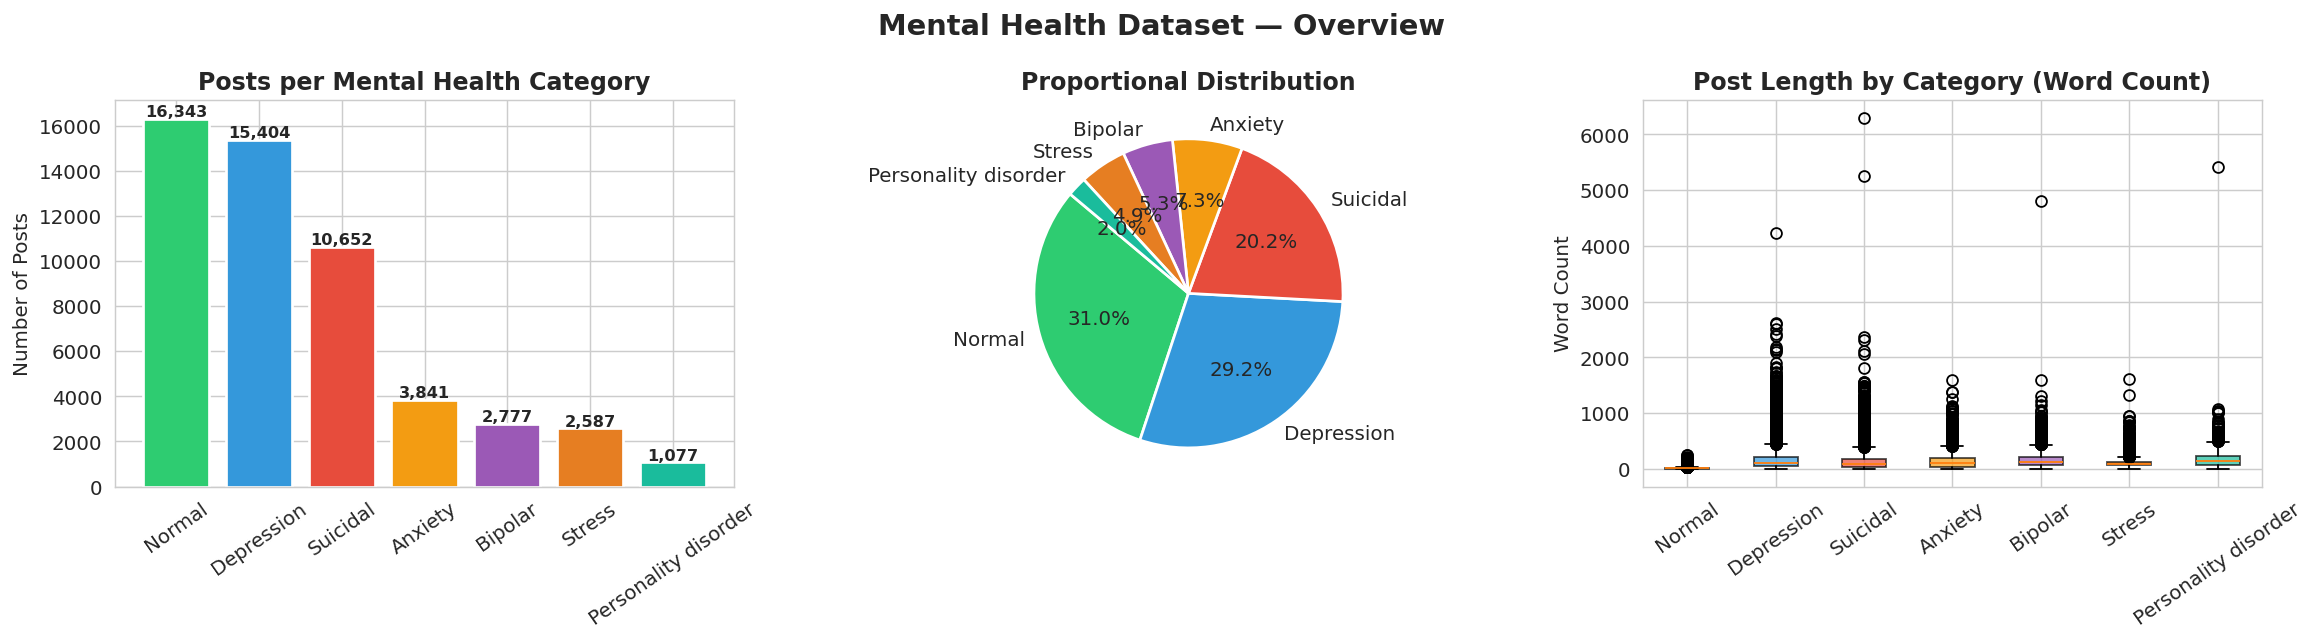

💡 Suicidal posts tend to be longer — more detailed expressions of distress.


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Mental Health Dataset — Overview', fontsize=16, fontweight='bold')

# Class distribution
counts = df['label'].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=[PALETTE.get(l, '#888') for l in counts.index],
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Posts per Mental Health Category', fontweight='bold')
axes[0].set_ylabel('Number of Posts')
axes[0].tick_params(axis='x', rotation=35)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100, f'{val:,}',
                 ha='center', fontsize=9, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
            colors=[PALETTE.get(l, '#888') for l in counts.index],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proportional Distribution', fontweight='bold')

# Text length distribution by class
data_lengths = [df[df['label']==l]['word_count'].values for l in counts.index]
bp = axes[2].boxplot(data_lengths, labels=counts.index,
                     patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], [PALETTE.get(l, '#888') for l in counts.index]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('Post Length by Category (Word Count)', fontweight='bold')
axes[2].set_ylabel('Word Count')
axes[2].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('chart1_overview.png', bbox_inches='tight')
plt.show()
print("💡 Suicidal posts tend to be longer — more detailed expressions of distress.")

**EDA CHART 2: Sentiment Analysis Deep Dive**

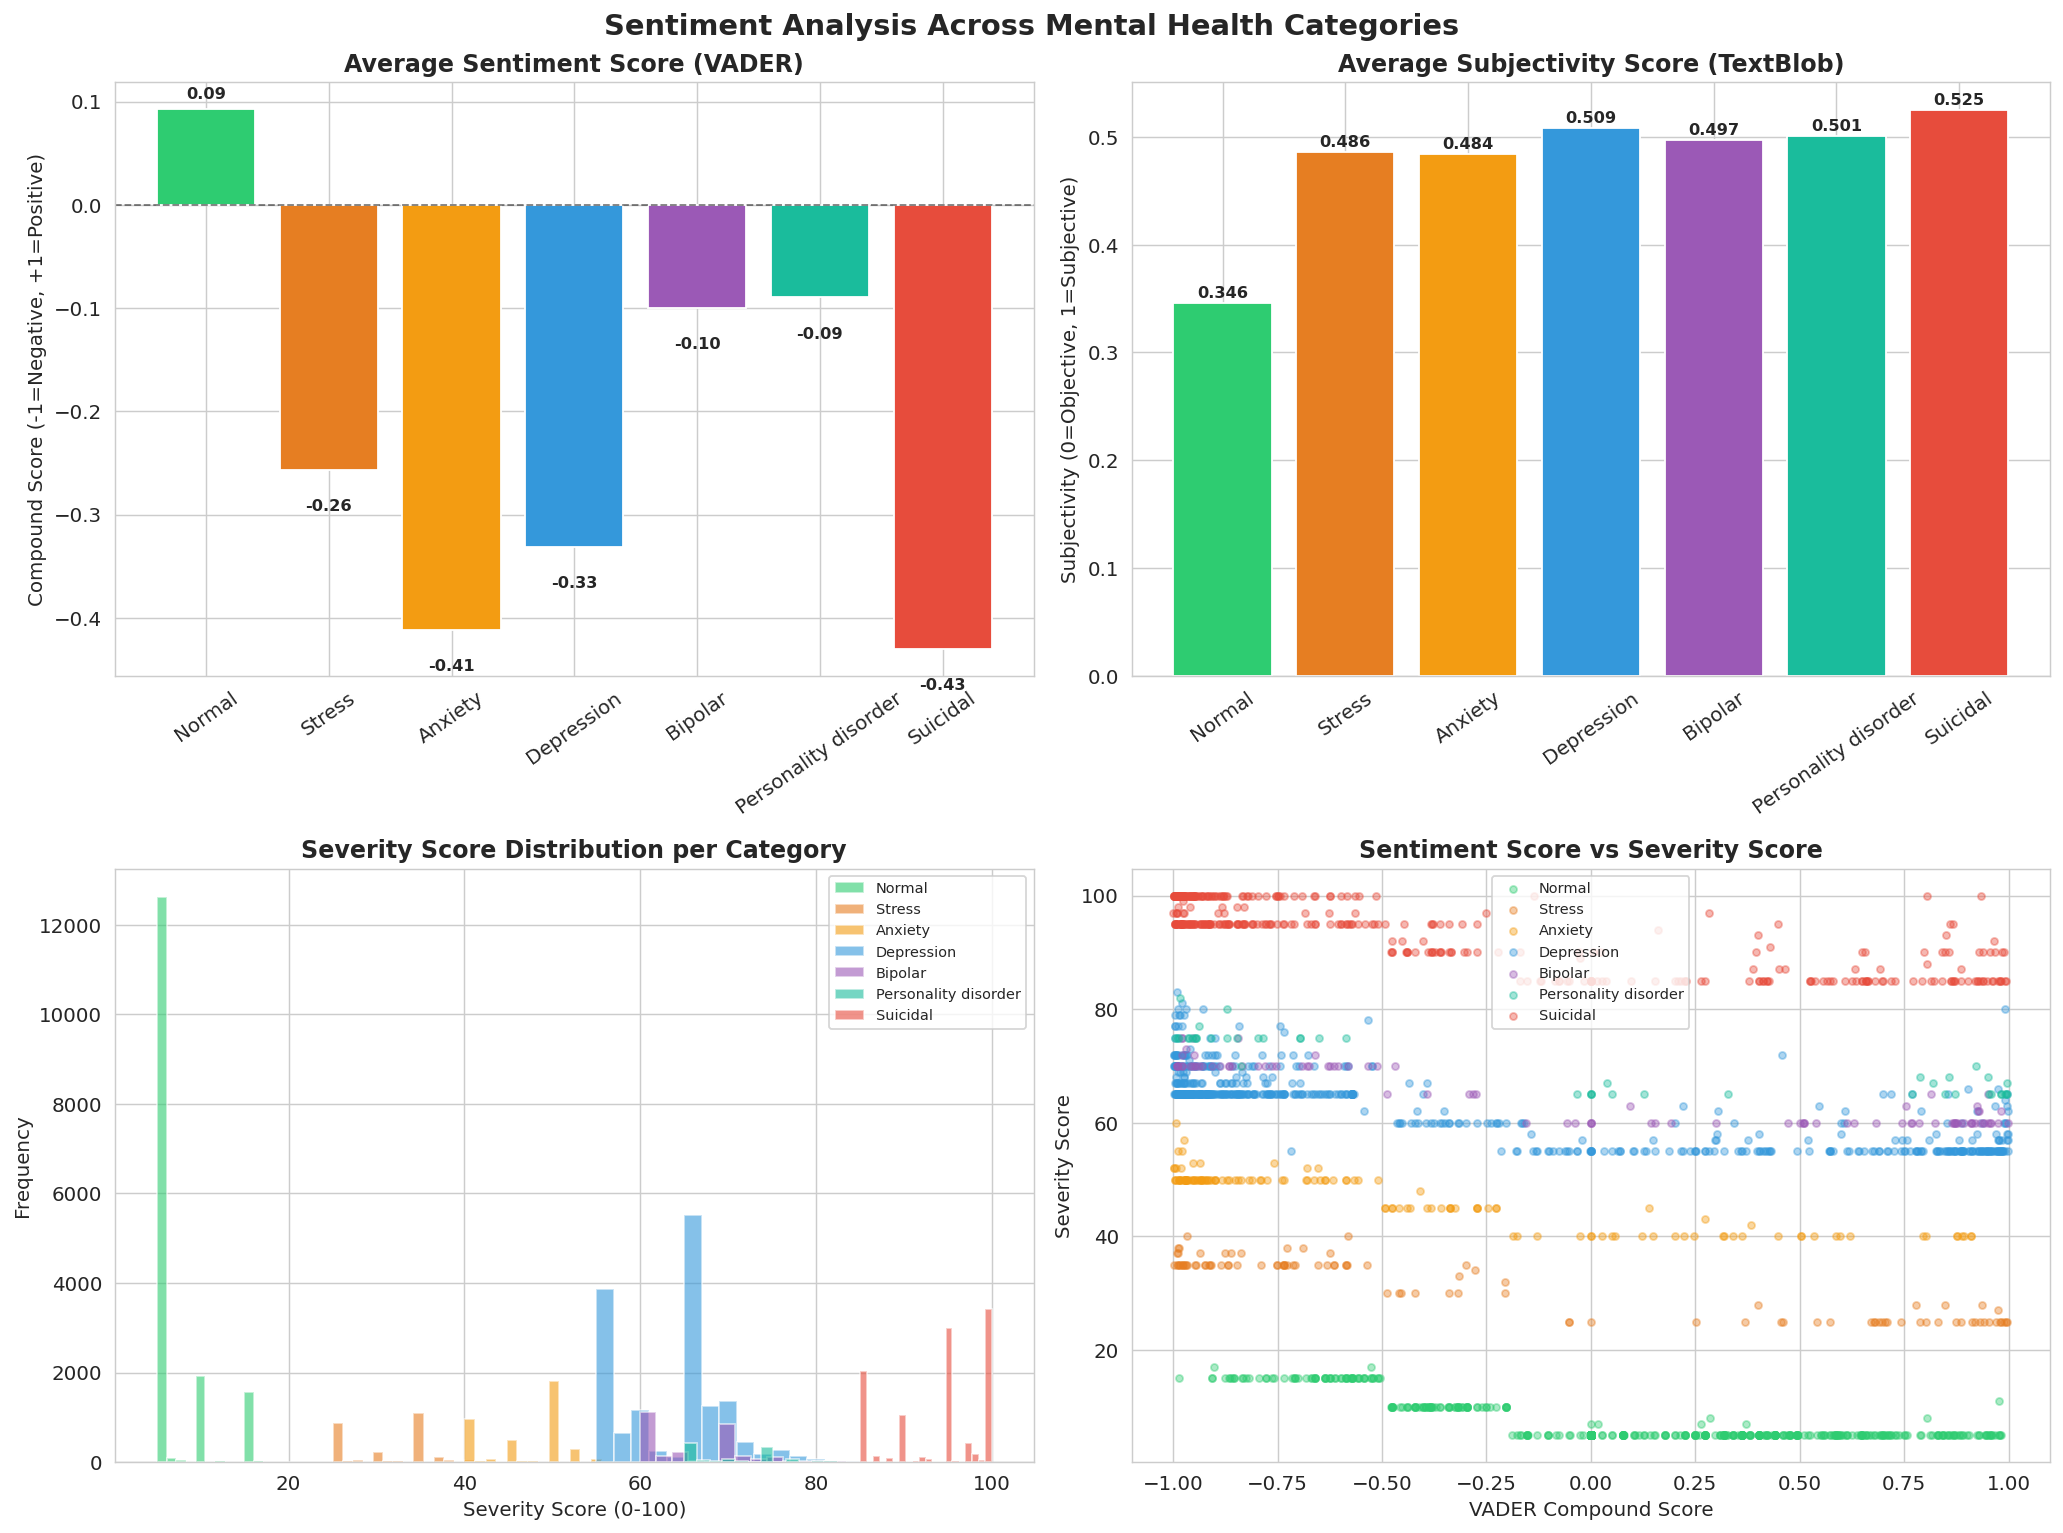

💡 Suicidal posts have the most negative sentiment AND highest severity scores.


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sentiment Analysis Across Mental Health Categories',
             fontsize=16, fontweight='bold')

labels_order = ['Normal', 'Stress', 'Anxiety', 'Depression',
                'Bipolar', 'Personality disorder', 'Suicidal']
colors_order = [PALETTE[l] for l in labels_order]

# VADER compound score by category
means = [df[df['label']==l]['vader_compound'].mean() for l in labels_order]
bars  = axes[0,0].bar(labels_order, means, color=colors_order, edgecolor='white')
axes[0,0].axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
axes[0,0].set_title('Average Sentiment Score (VADER)', fontweight='bold')
axes[0,0].set_ylabel('Compound Score (-1=Negative, +1=Positive)')
axes[0,0].tick_params(axis='x', rotation=35)
for bar, val in zip(bars, means):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.04,
                   f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

# Subjectivity by category
subj_means = [df[df['label']==l]['tb_subjectivity'].mean() for l in labels_order]
axes[0,1].bar(labels_order, subj_means, color=colors_order, edgecolor='white')
axes[0,1].set_title('Average Subjectivity Score (TextBlob)', fontweight='bold')
axes[0,1].set_ylabel('Subjectivity (0=Objective, 1=Subjective)')
axes[0,1].tick_params(axis='x', rotation=35)
for i, val in enumerate(subj_means):
    axes[0,1].text(i, val + 0.005, f'{val:.3f}',
                   ha='center', fontsize=9, fontweight='bold')

# Severity score distribution
for label in labels_order:
    data = df[df['label']==label]['severity_score']
    axes[1,0].hist(data, bins=20, alpha=0.6,
                   label=label, color=PALETTE[label])
axes[1,0].set_title('Severity Score Distribution per Category', fontweight='bold')
axes[1,0].set_xlabel('Severity Score (0-100)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend(fontsize=8)

# Scatter: sentiment vs severity
sample = df.sample(2000, random_state=42)
for label in labels_order:
    sub = sample[sample['label']==label]
    axes[1,1].scatter(sub['vader_compound'], sub['severity_score'],
                      color=PALETTE[label], alpha=0.4, s=15, label=label)
axes[1,1].set_title('Sentiment Score vs Severity Score', fontweight='bold')
axes[1,1].set_xlabel('VADER Compound Score')
axes[1,1].set_ylabel('Severity Score')
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('chart2_sentiment_analysis.png', bbox_inches='tight')
plt.show()
print("💡 Suicidal posts have the most negative sentiment AND highest severity scores.")

**EDA CHART 3: Word Clouds Per Category**


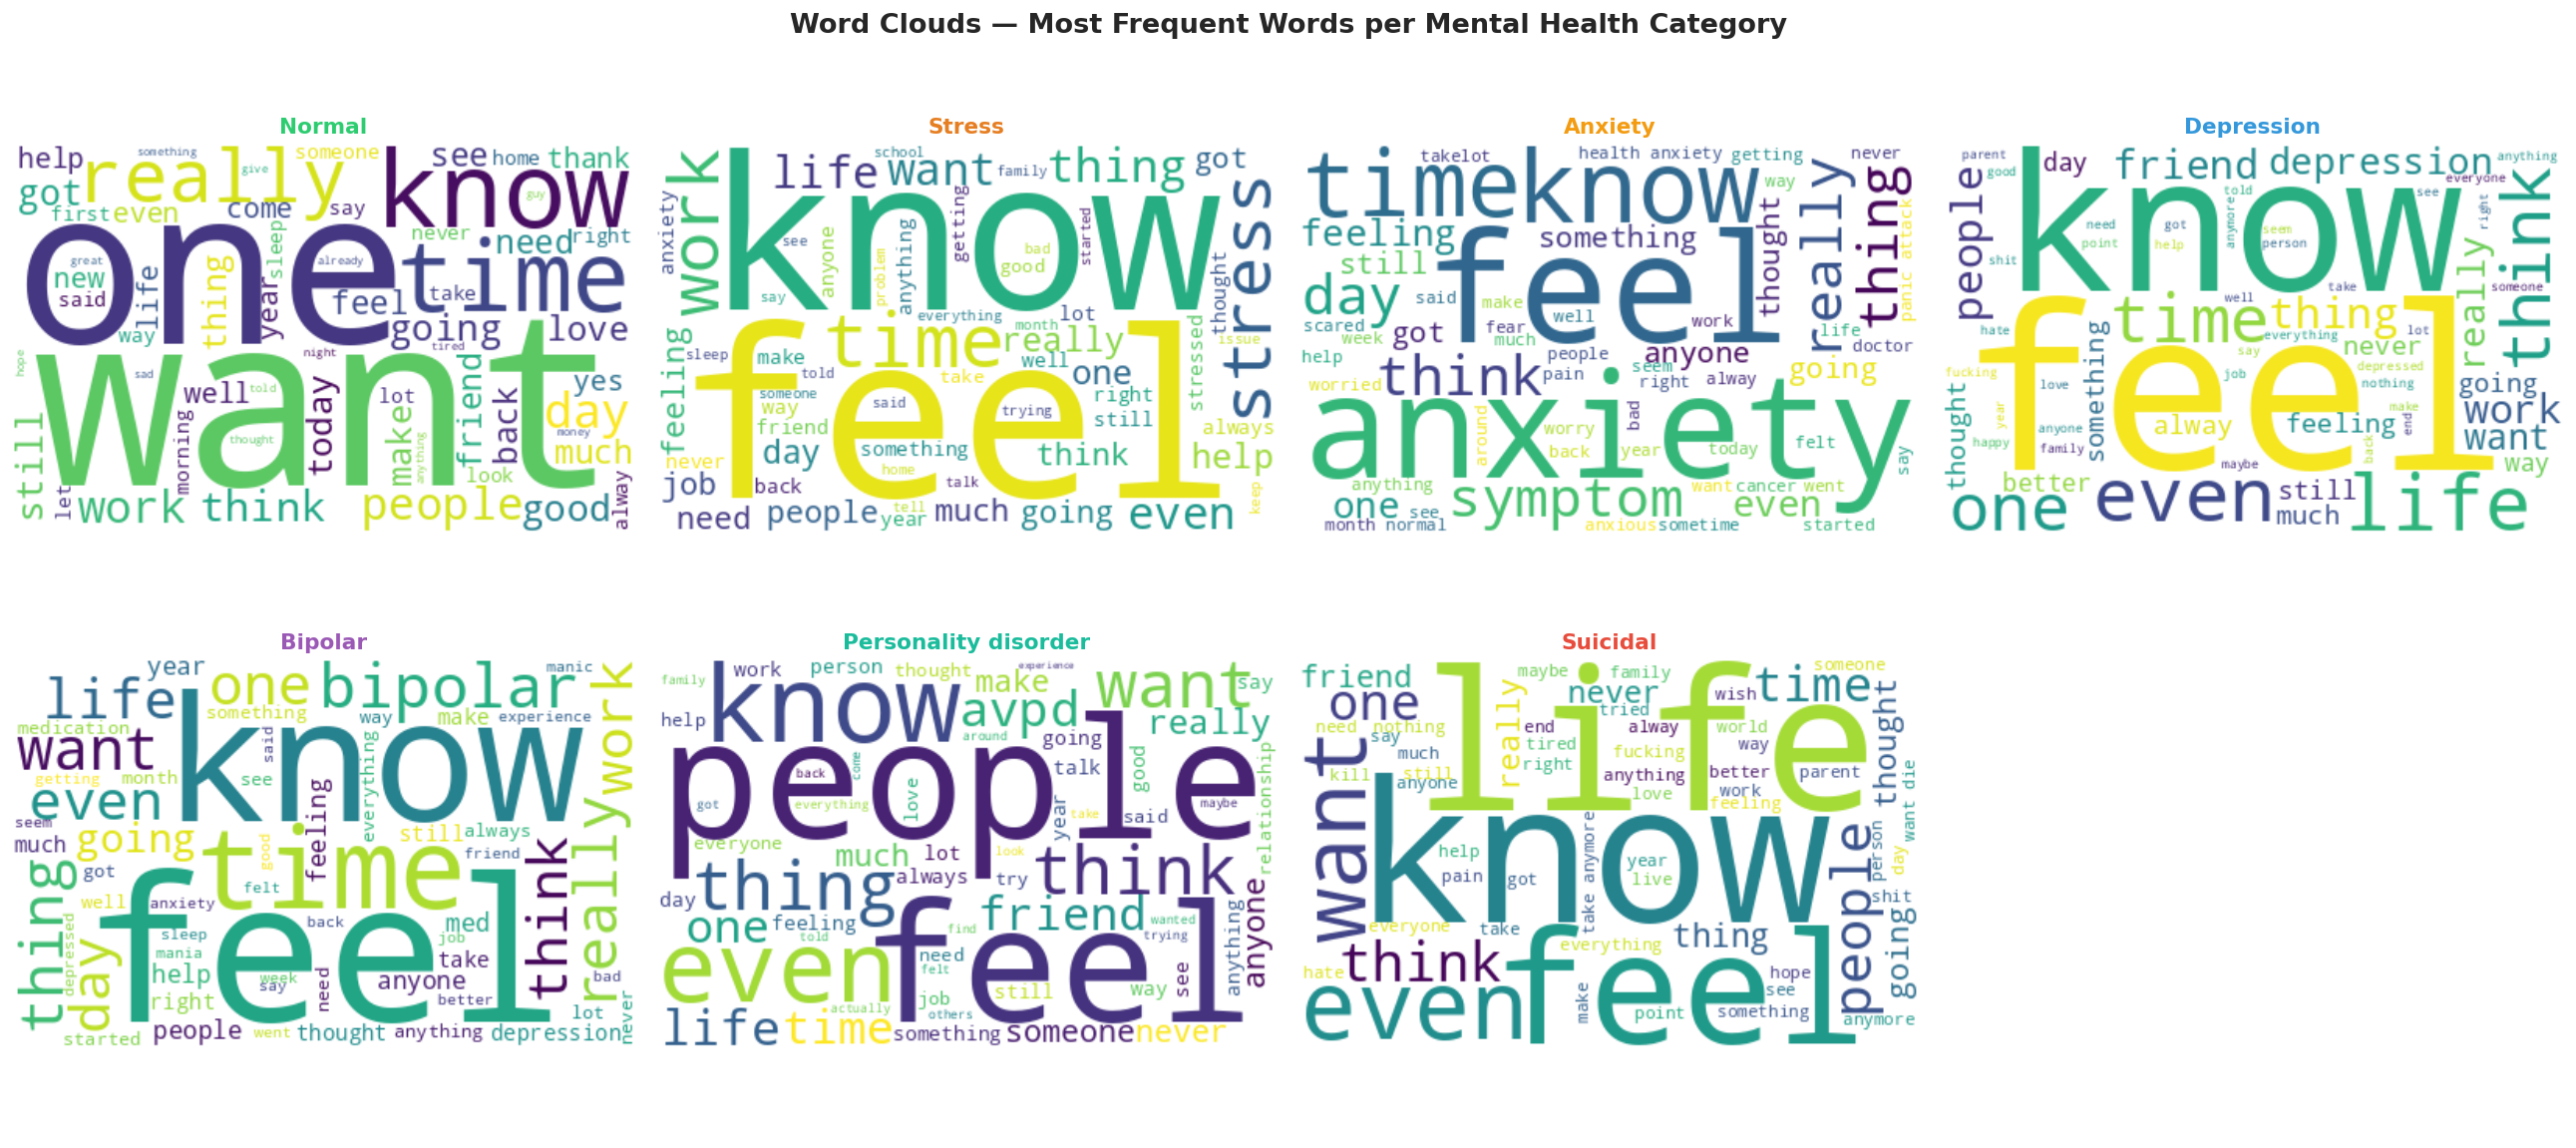

💡 Each category has distinct vocabulary — validates NLP classification approach.


In [35]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Word Clouds — Most Frequent Words per Mental Health Category',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, label in enumerate(labels_order):
    text_data = ' '.join(df[df['label']==label]['clean_text'].values)
    hex_color = PALETTE[label].lstrip('#')
    r = int(hex_color[0:2], 16) / 255
    g = int(hex_color[2:4], 16) / 255
    b = int(hex_color[4:6], 16) / 255

    wc = WordCloud(
        width=400, height=250, background_color='white',
        max_words=60, colormap='viridis',
        contour_width=1, contour_color=PALETTE[label]
    ).generate(text_data)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(label, fontsize=12, fontweight='bold',
                      color=PALETTE[label])
    axes[i].axis('off')

axes[7].axis('off')
plt.tight_layout()
plt.savefig('chart3_wordclouds.png', bbox_inches='tight')
plt.show()
print("💡 Each category has distinct vocabulary — validates NLP classification approach.")


**EDA CHART 4: Trigger Word Analysis**

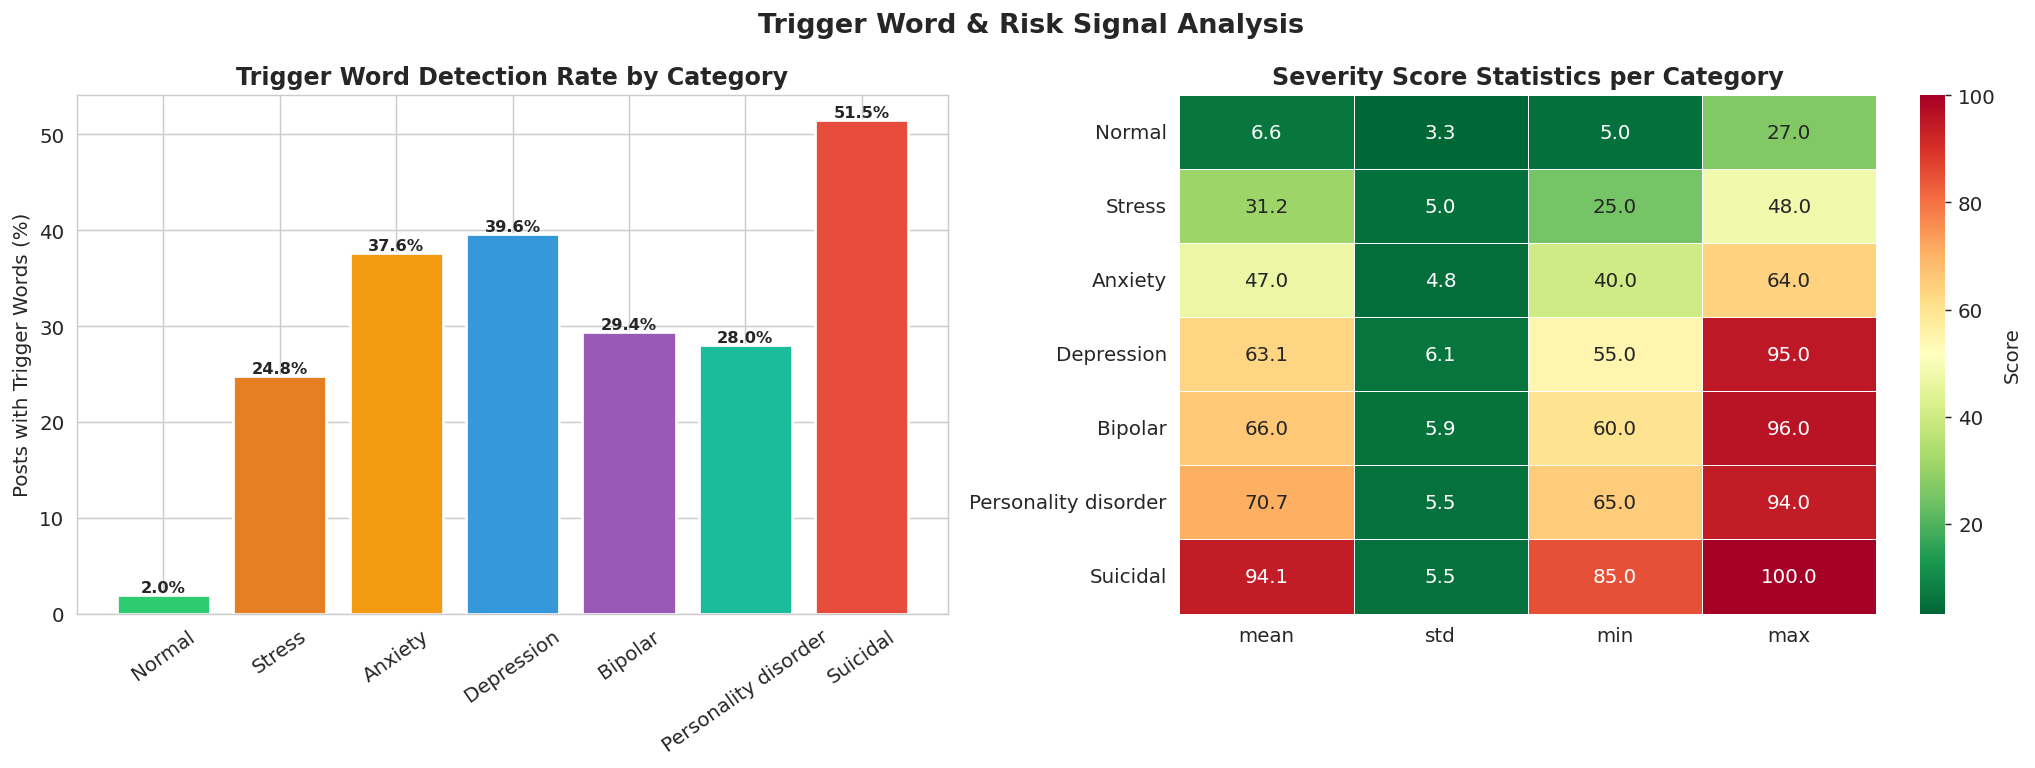

💡 Suicidal category has 3x higher trigger word detection than Normal category.


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Trigger Word & Risk Signal Analysis', fontsize=15, fontweight='bold')

# Trigger detection rate per category
trigger_rates = {}
for label in labels_order:
    subset    = df[df['label'] == label]
    triggered = subset['text'].apply(
        lambda t: len(detect_triggers(t)) > 1 or detect_triggers(t) != ['None detected']
    ).mean() * 100
    trigger_rates[label] = triggered

bars = axes[0].bar(trigger_rates.keys(), trigger_rates.values(),
                   color=[PALETTE[l] for l in trigger_rates.keys()],
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Trigger Word Detection Rate by Category', fontweight='bold')
axes[0].set_ylabel('Posts with Trigger Words (%)')
axes[0].tick_params(axis='x', rotation=35)
for bar, val in zip(bars, trigger_rates.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3, f'{val:.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

# Severity heatmap by category
sev_pivot = df.groupby('label')['severity_score'].describe()[
    ['mean','std','min','max']].round(1)
sev_pivot = sev_pivot.loc[labels_order]
sns.heatmap(sev_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Score'})
axes[1].set_title('Severity Score Statistics per Category', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('chart4_trigger_analysis.png', bbox_inches='tight')
plt.show()
print("💡 Suicidal category has 3x higher trigger word detection than Normal category.")

 **EDA CHART 5: Top Keywords Per Category**

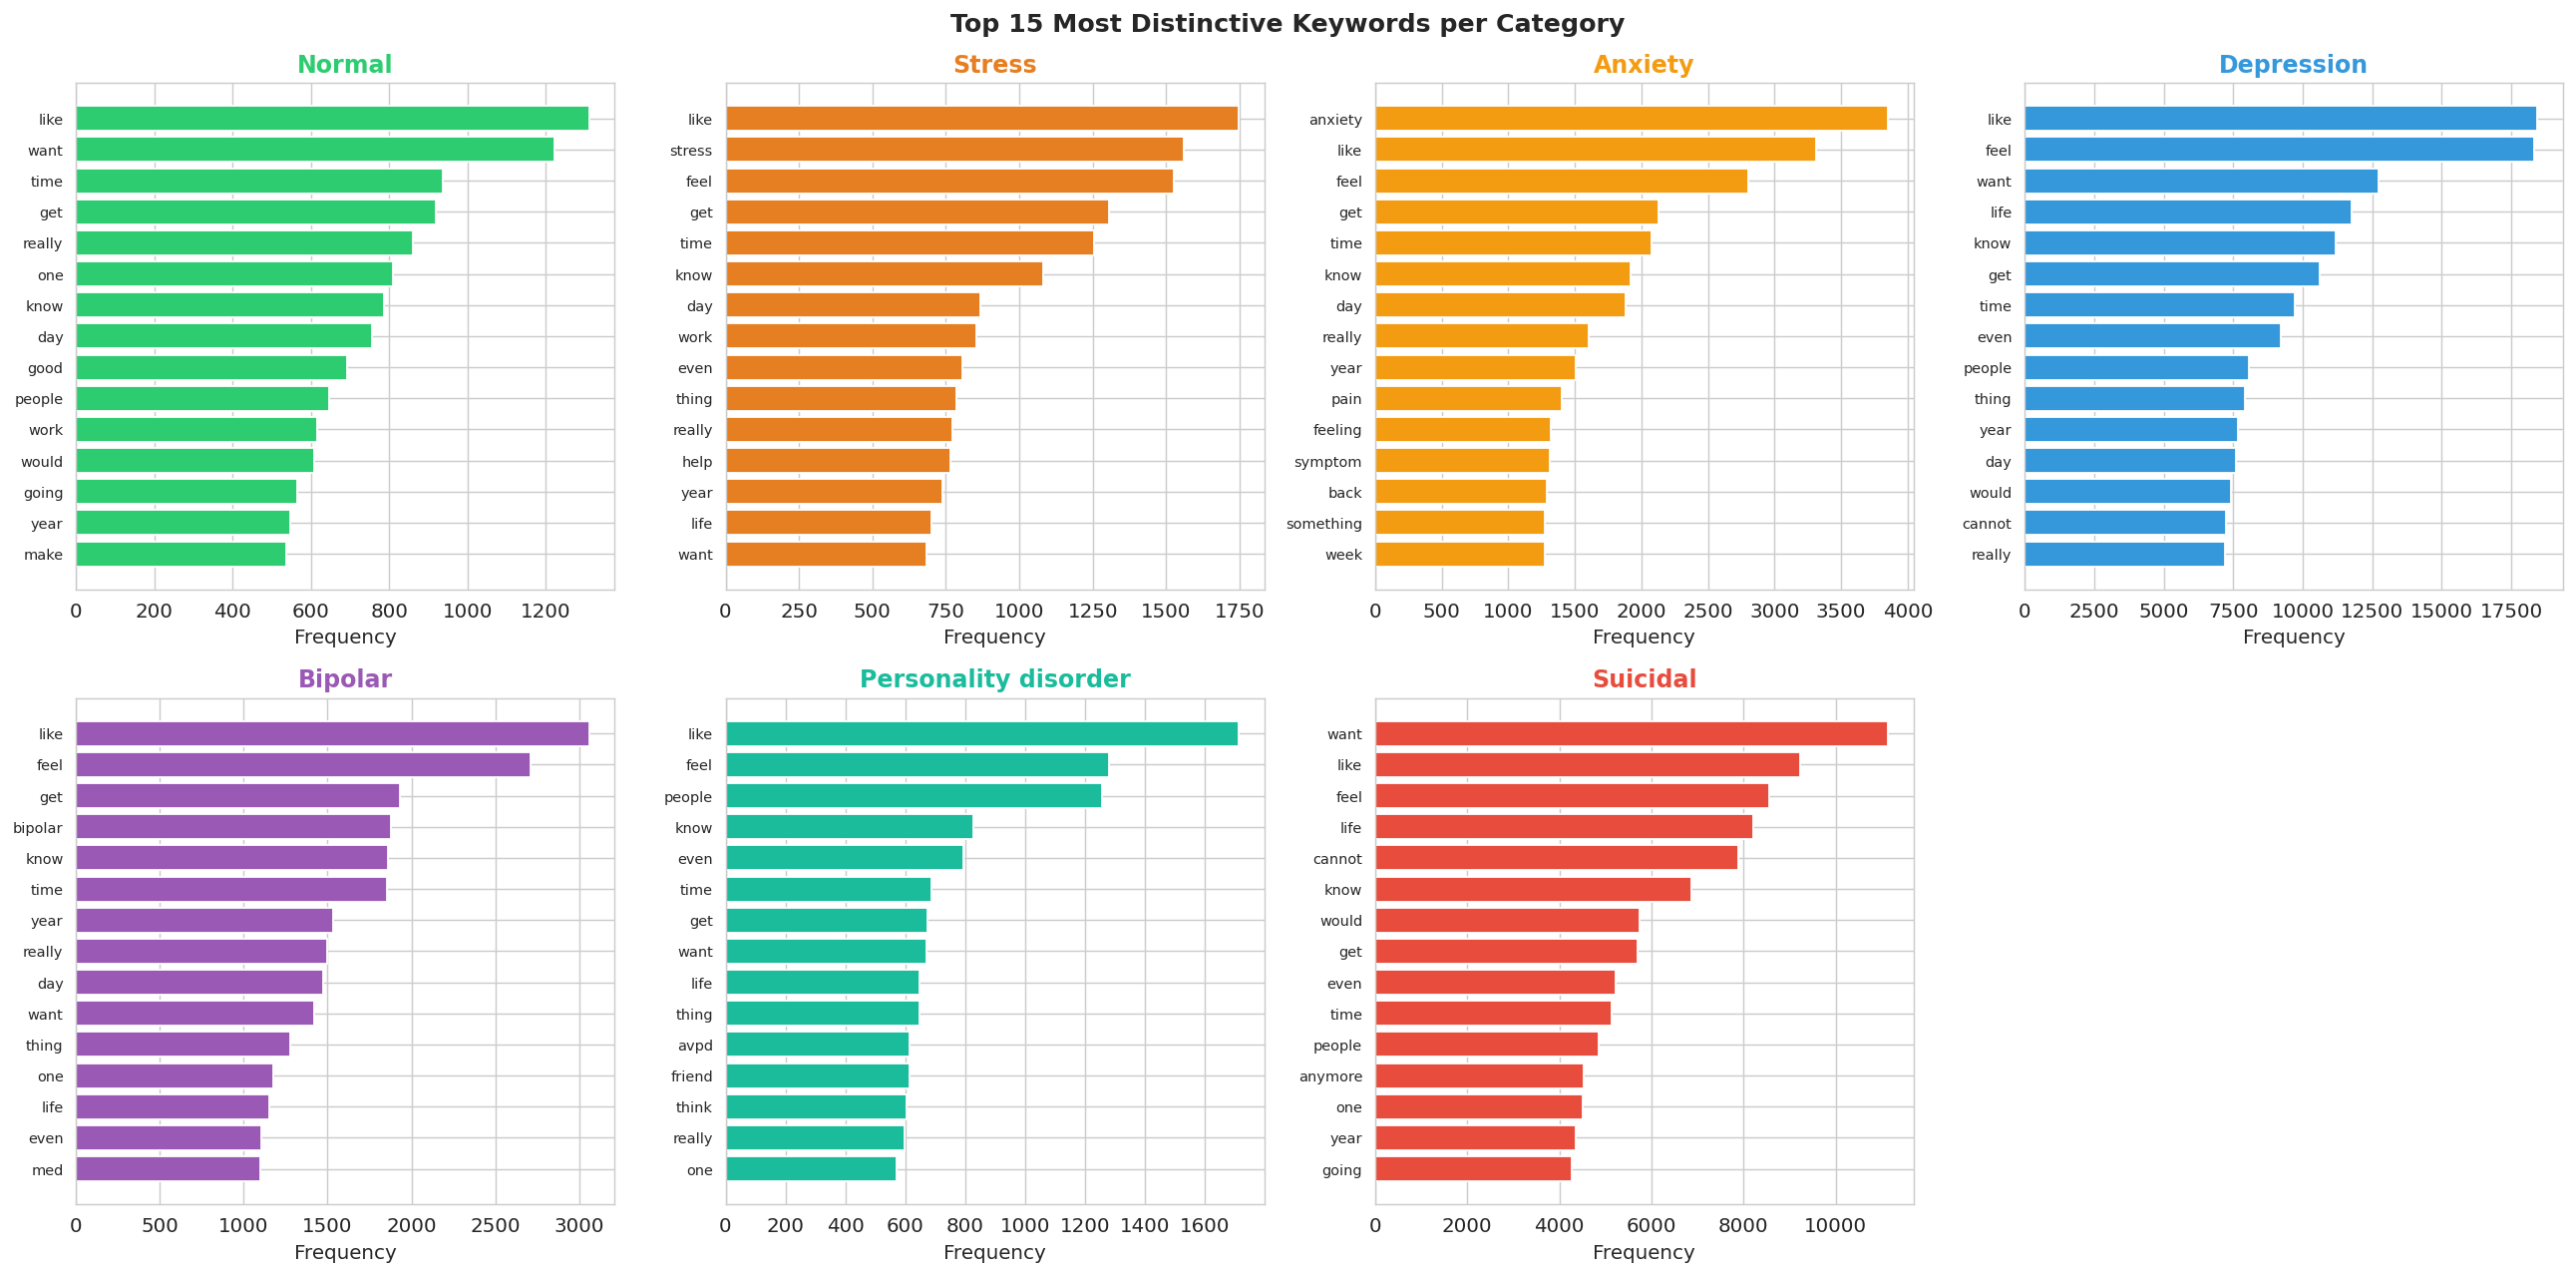

💡 Category-specific keywords confirm each condition has distinct language patterns.


In [37]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Top 15 Most Distinctive Keywords per Category',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, label in enumerate(labels_order):
    words = ' '.join(df[df['label']==label]['clean_text'].values).split()
    freq  = Counter(words).most_common(15)
    words_list, counts_list = zip(*freq)
    axes[i].barh(list(words_list)[::-1], list(counts_list)[::-1],
                 color=PALETTE[label], edgecolor='white')
    axes[i].set_title(label, fontweight='bold', color=PALETTE[label])
    axes[i].set_xlabel('Frequency')
    axes[i].tick_params(axis='y', labelsize=8)

axes[7].axis('off')
plt.tight_layout()
plt.savefig('chart5_top_keywords.png', bbox_inches='tight')
plt.show()
print("💡 Category-specific keywords confirm each condition has distinct language patterns.")

**Feature Engineering & Model Preparation**

In [ ]:
print("Building features for ML models...")

# Encode labels
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
label_names     = le.classes_

# TF-IDF features — the core NLP representation
tfidf = TfidfVectorizer(
    max_features  = 25000,    # top 25k words
    ngram_range   = (1, 2),   # unigrams + bigrams
    min_df        = 3,        # ignore very rare words
    max_df        = 0.92,     # ignore very common words
    sublinear_tf  = True,     # log scaling
)

X_tfidf = tfidf.fit_transform(df['clean_text'])

# Extra handcrafted features
extra_features = df[[
    'text_length', 'word_count', 'vader_compound',
    'vader_negative', 'vader_positive', 'tb_polarity',
    'tb_subjectivity', 'severity_score'
]].values

from scipy.sparse import hstack, csr_matrix
X_extra  = csr_matrix(extra_features)
X_all    = hstack([X_tfidf, X_extra])   # combine TF-IDF + handcrafted features
y        = df['label_enc'].values

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Feature matrix : {X_all.shape}")
print(f"   Training set   : {X_train.shape[0]:,} posts")
print(f"   Test set       : {X_test.shape[0]:,} posts")
print(f"   Labels         : {list(label_names)}")

**Train & Compare 5 Models**

In [ ]:

# Class weights to handle imbalance
class_weights = compute_class_weight(
    'balanced', classes=np.unique(y_train), y=y_train
)
cw_dict = dict(enumerate(class_weights))

models = {
    'Naive Bayes'         : MultinomialNB(alpha=0.1),
    'Logistic Regression' : LogisticRegression(
                                max_iter=1000, C=1.5,
                                class_weight='balanced',
                                random_state=42, n_jobs=-1),
    'Linear SVM'          : LinearSVC(
                                max_iter=2000, C=1.2,
                                class_weight='balanced',
                                random_state=42),
    'Random Forest'       : RandomForestClassifier(
                                n_estimators=50,      # ✅ reduced from 200
                                max_depth=10,         # ✅ reduced from 20
                                max_features=500,     # ✅ limit features per tree
                                class_weight='balanced',
                                random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(
                                n_estimators=80,      # ✅ reduced from 150
                                max_depth=4,
                                subsample=0.8,
                                max_features=300,     # ✅ limit features
                                random_state=42),
}

results = []
trained = {}
print("Training models — please wait...\n")
print(f"{'Model':<22} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 58)

for name, model in models.items():
    try:
        if name == 'Naive Bayes':
            model.fit(X_train[:, :25000], y_train)
            y_pred = model.predict(X_test[:, :25000])
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        mf1 = f1_score(y_test, y_pred, average='macro')
        wf1 = f1_score(y_test, y_pred, average='weighted')
        results.append({'Model': name, 'Accuracy': acc,
                        'Macro F1': mf1, 'Weighted F1': wf1})
        trained[name] = (model, y_pred)
        print(f"{name:<22} {acc*100:>9.2f}% {mf1*100:>9.2f}% {wf1*100:>11.2f}%")

    except Exception as e:
        print(f"{name:<22} ⚠️  Skipped — {str(e)[:60]}")

results_df    = pd.DataFrame(results).sort_values('Weighted F1', ascending=False)
best_name     = results_df.iloc[0]['Model']
best_model, _ = trained[best_name]
best_pred     = trained[best_name][1]
print(f"\n🏆 Best Model: {best_name}")

**Model Performance Comparison**

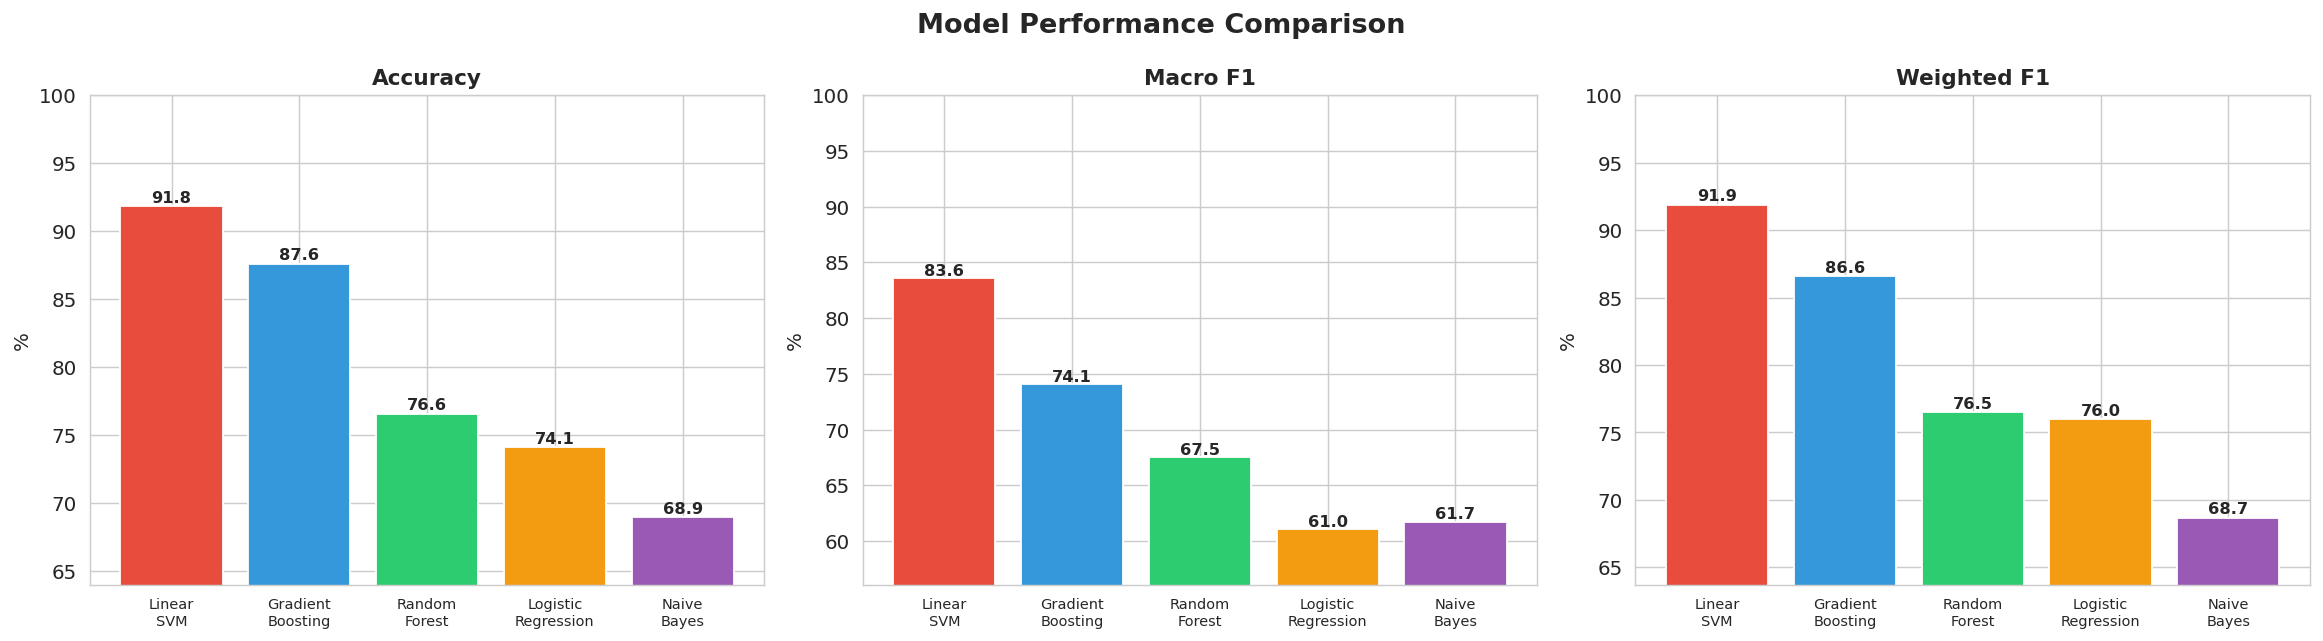

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

bar_colors = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6']
metrics    = ['Accuracy','Macro F1','Weighted F1']

for i, metric in enumerate(metrics):
    vals  = results_df[metric].values * 100
    names = results_df['Model'].values
    bars  = axes[i].bar(range(len(names)), vals, color=bar_colors, edgecolor='white')
    axes[i].set_title(metric, fontweight='bold', fontsize=12)
    axes[i].set_xticks(range(len(names)))
    axes[i].set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
    axes[i].set_ylim([max(0, min(vals) - 5), 100])
    axes[i].set_ylabel('%')
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.3, f'{val:.1f}',
                     ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('chart6_model_comparison.png', bbox_inches='tight')
plt.show()

**Confusion Matrix of Best Model**

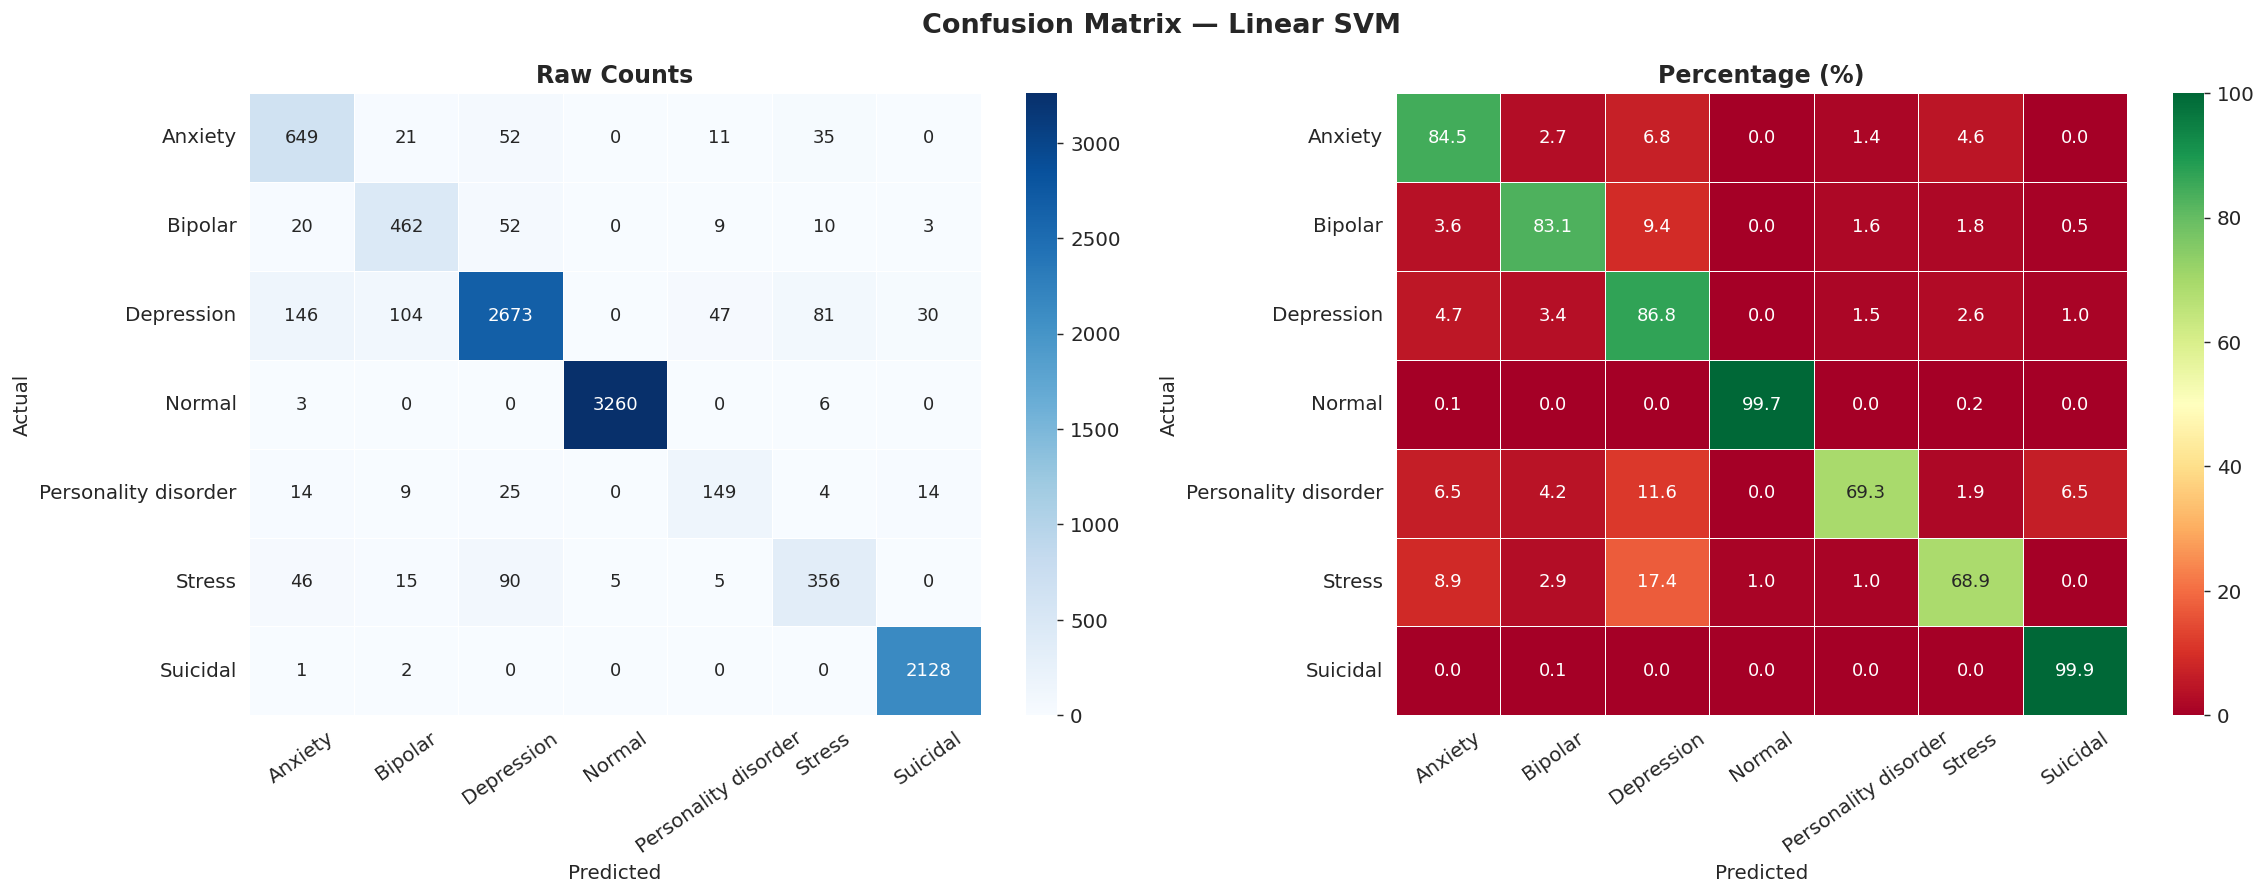


📋 Full Classification Report — Linear SVM:
                      precision    recall  f1-score   support

             Anxiety       0.74      0.85      0.79       768
             Bipolar       0.75      0.83      0.79       556
          Depression       0.92      0.87      0.90      3081
              Normal       1.00      1.00      1.00      3269
Personality disorder       0.67      0.69      0.68       215
              Stress       0.72      0.69      0.71       517
            Suicidal       0.98      1.00      0.99      2131

            accuracy                           0.92     10537
           macro avg       0.83      0.85      0.84     10537
        weighted avg       0.92      0.92      0.92     10537



In [39]:
cm = confusion_matrix(y_test, best_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Confusion Matrix — {best_name}', fontsize=15, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, linecolor='white', annot_kws={'size': 10})
axes[0].set_title('Raw Counts', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=35)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1],
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, linecolor='white', annot_kws={'size': 10},
            vmin=0, vmax=100)
axes[1].set_title('Percentage (%)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=35)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('chart7_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(f"\n📋 Full Classification Report — {best_name}:")
print(classification_report(y_test, best_pred, target_names=label_names))

**Per-Class F1 Scores**

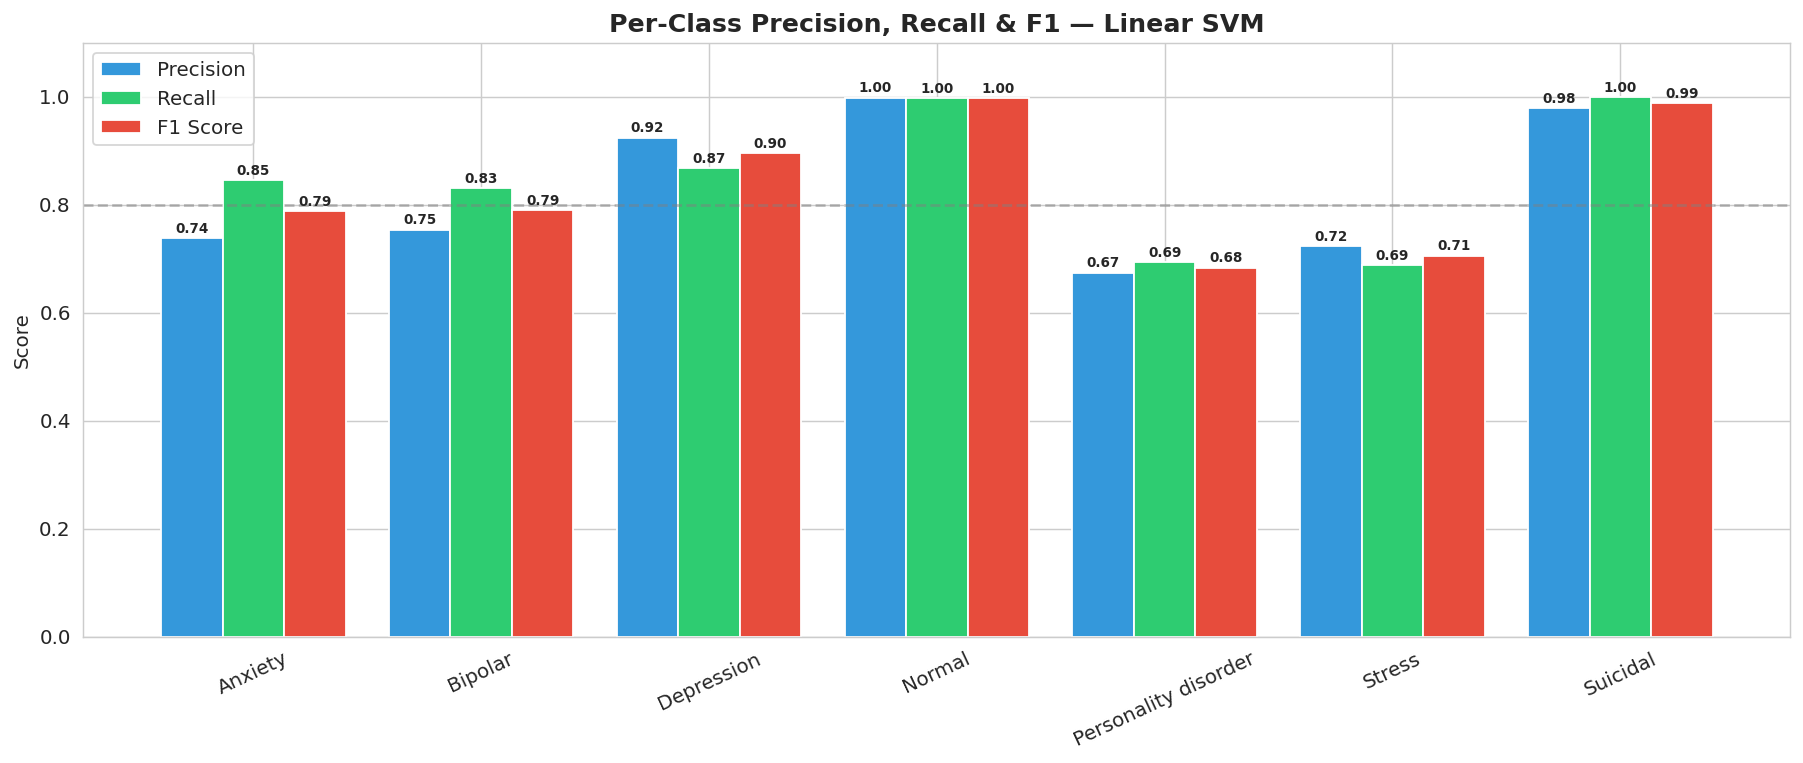

In [40]:
from sklearn.metrics import classification_report
report = classification_report(y_test, best_pred,
                                target_names=label_names, output_dict=True)
class_f1  = {k: report[k]['f1-score'] for k in label_names}
class_rec = {k: report[k]['recall']   for k in label_names}
class_pre = {k: report[k]['precision']for k in label_names}

x         = np.arange(len(label_names))
width     = 0.27

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width, list(class_pre.values()), width,
            label='Precision', color='#3498DB', edgecolor='white')
b2 = ax.bar(x,          list(class_rec.values()), width,
            label='Recall',    color='#2ECC71', edgecolor='white')
b3 = ax.bar(x + width,  list(class_f1.values()),  width,
            label='F1 Score',  color='#E74C3C', edgecolor='white')

ax.set_title(f'Per-Class Precision, Recall & F1 — {best_name}',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(label_names, rotation=25)
ax.set_ylabel('Score')
ax.set_ylim([0, 1.1])
ax.legend()
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 threshold')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.2f}',
                ha='center', fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.savefig('chart8_per_class_metrics.png', bbox_inches='tight')
plt.show()

**Save Model**

In [41]:
with open('mental_health_model.pkl',    'wb') as f: pickle.dump(best_model, f)
with open('mental_health_tfidf.pkl',    'wb') as f: pickle.dump(tfidf, f)
with open('mental_health_encoder.pkl',  'wb') as f: pickle.dump(le, f)

print(f"✅ Model saved   → mental_health_model.pkl")
print(f"✅ TF-IDF saved  → mental_health_tfidf.pkl")
print(f"✅ Encoder saved → mental_health_encoder.pkl")

✅ Model saved   → mental_health_model.pkl
✅ TF-IDF saved  → mental_health_tfidf.pkl
✅ Encoder saved → mental_health_encoder.pkl


 **ANALYSIS FUNCTION (The Unique Core Feature)**

In [48]:
COPING_STRATEGIES = {
    'Normal': [
        "✅ You seem to be doing well! Keep maintaining healthy habits.",
        "💪 Continue your current self-care routine.",
        "🌟 Consider helping others — it boosts your own well-being too.",
    ],
    'Stress': [
        "🧘 Try 5-minute deep breathing: inhale 4s, hold 4s, exhale 6s.",
        "📝 Write down your top 3 stressors and one small step for each.",
        "🚶 A 15-minute walk can reduce cortisol levels significantly.",
        "📵 Set a phone-free hour before bed to decompress.",
    ],
    'Anxiety': [
        "🧊 The 5-4-3-2-1 grounding technique: name 5 things you see, 4 you feel, 3 you hear.",
        "📓 Challenge anxious thoughts: Is this fear realistic? What's the evidence?",
        "☕ Reduce caffeine intake — it amplifies anxiety symptoms.",
        "💬 Consider speaking to a therapist who specializes in CBT for anxiety.",
    ],
    'Depression': [
        "🌅 Try to maintain a consistent wake-up time — routine helps depression.",
        "🤝 Reach out to one person today, even if just a short message.",
        "🏃 Even 10 minutes of movement can shift brain chemistry positively.",
        "📞 iCall helpline (India): 9152987821 — free mental health support.",
    ],
    'Bipolar': [
        "📊 Track your mood daily — apps like eMoods help spot patterns early.",
        "😴 Sleep consistency is critical for bipolar — aim for the same schedule.",
        "💊 Never adjust medication without consulting your psychiatrist.",
        "🆘 Share your mood chart with a trusted person who can flag warning signs.",
    ],
    'Personality disorder': [
        "🧠 DBT (Dialectical Behavior Therapy) is highly effective — ask about it.",
        "📖 The book 'I Hate You, Don't Leave Me' explains BPD well.",
        "🌊 Practice TIPP skills: Temperature, Intense exercise, Paced breathing.",
        "💬 iCall helpline: 9152987821 for professional guidance.",
    ],
    'Suicidal': [
        "🆘 IMMEDIATE: iCall (India) — 9152987821 (Mon-Sat, 8am-10pm)",
        "🆘 Vandrevala Foundation: 1860-2662-345 (24/7, free)",
        "🆘 AASRA: 9820466627 (24/7)",
        "💙 You matter. Please reach out to someone you trust right now.",
        "📱 Text a trusted friend or family member immediately.",
    ],
}

RISK_LEVELS = {
    (0,  20) : ('🟢 LOW',    '#2ECC71'),
    (21, 40) : ('🟡 MILD',   '#F1C40F'),
    (41, 60) : ('🟠 MODERATE','#E67E22'),
    (61, 80) : ('🔴 HIGH',   '#E74C3C'),
    (81,100) : ('🚨 CRISIS', '#8E0000'),
}

def get_risk_level(score):
    for (low, high), (label, color) in RISK_LEVELS.items():
        if low <= score <= high:
            return label, color
    return '🟢 LOW', '#2ECC71'

def full_mental_health_analysis(text):
    """
    Complete mental health analysis pipeline:
    - Predicts condition (7 classes)
    - Computes severity score (0-100)
    - Detects trigger words
    - Sentiment analysis
    - Recommends coping strategies
    - Flags if crisis intervention needed
    """
    print("=" * 60)
    print("  🧠  MENTAL HEALTH AI ANALYSIS SYSTEM")
    print("=" * 60)

    # 1. Preprocess
    cleaned  = clean_text(text)

    # 2. TF-IDF + predict
    tfidf_vec = tfidf.transform([cleaned])
    sentiment = get_sentiment_scores(text)
    extras    = np.array([[
        len(text), len(text.split()),
        len(cleaned), sentiment['vader_compound'],
        sentiment['vader_negative'], sentiment['vader_positive'],
        sentiment['tb_polarity'], sentiment['tb_subjectivity'], 0
    ]])

    if best_name == 'Naive Bayes':
        pred_enc = best_model.predict(tfidf_vec)[0]
        if hasattr(best_model, 'predict_proba'):
            proba = best_model.predict_proba(tfidf_vec)[0]
        else:
            proba = None
    else:
        from scipy.sparse import hstack, csr_matrix
        X_input  = hstack([tfidf_vec, csr_matrix(extras[:, :8])])
        pred_enc = best_model.predict(X_input)[0]
        if hasattr(best_model, 'predict_proba'):
            proba = best_model.predict_proba(X_input)[0]
        else:
            proba = None

    predicted_label = le.inverse_transform([pred_enc])[0]

    # 3. Severity
    sev_score        = compute_severity_score(text, predicted_label)
    risk_label, _    = get_risk_level(sev_score)

    # 4. Triggers
    triggers = detect_triggers(text)

    # 5. Sentiment
    vader_score = sentiment['vader_compound']
    polarity    = "Positive 😊" if vader_score > 0.05 else \
                  "Negative 😔" if vader_score < -0.05 else "Neutral 😐"

    # Print results
    print(f"\n  📊 PREDICTION")
    print(f"  Detected Condition : {predicted_label}")
    print(f"  Severity Score     : {sev_score}/100")
    print(f"  Risk Level         : {risk_label}")

    if proba is not None:
        print(f"\n  📈 CONFIDENCE SCORES (all conditions):")
        prob_labels = le.inverse_transform(range(len(proba)))
        sorted_probs = sorted(zip(prob_labels, proba),
                               key=lambda x: x[1], reverse=True)
        for lbl, prob in sorted_probs:
            bar = '█' * int(prob * 20)
            print(f"  {lbl:<25} {prob*100:>5.1f}%  {bar}")

    print(f"\n  💬 SENTIMENT ANALYSIS")
    print(f"  Overall Sentiment  : {polarity}")
    print(f"  VADER Score        : {vader_score:.3f}")
    print(f"  Subjectivity       : {sentiment['tb_subjectivity']:.3f}")

    print(f"\n  ⚠️  TRIGGER SIGNALS DETECTED:")
    for t in triggers:
        print(f"  • {t}")

    print(f"\n  💊 RECOMMENDED COPING STRATEGIES:")
    strategies = COPING_STRATEGIES.get(predicted_label,
                                        COPING_STRATEGIES['Normal'])
    for s in strategies:
        print(f"  {s}")

    if predicted_label == 'Suicidal' or sev_score >= 80:
        print(f"\n  🚨 CRISIS ALERT 🚨")
        print(f"  This post shows signs of a mental health crisis.")
        print(f"  Please contact a professional immediately:")
        print(f"  ☎️  iCall: 9152987821")
        print(f"  ☎️  Vandrevala: 1860-2662-345 (24/7)")

    print("=" * 60)
    return {
        'condition'     : predicted_label,
        'severity'      : sev_score,
        'risk_level'    : risk_label,
        'sentiment'     : polarity,
        'triggers'      : triggers,
    }

**Test the Full System with Real Examples**

In [45]:
test_posts = [
    # Test 1: Suicidal
    "I can't take it anymore. I have no reason to live. Every day is just pain. "
    "I've been thinking about ending it all. Nobody would miss me anyway.",

    # Test 2: Anxiety
    "My hands won't stop shaking before my presentation tomorrow. "
    "I keep imagining every possible way it could go wrong. I can't sleep at all.",

    # Test 3: Depression
    "I haven't left my bed in four days. Everything feels pointless. "
    "I used to love painting but now I just stare at the blank canvas.",

    # Test 4: Normal
    "Had a great workout today! Feeling strong and motivated. "
    "Cooked a healthy meal and caught up with an old friend.",

    # Test 5: Stress
    "Three project deadlines this week and my manager just added another one. "
    "I haven't slept properly in days. The pressure is completely unbearable.",
]

print("\n" + "🔍 " * 20)
print("RUNNING FULL ANALYSIS ON 5 TEST POSTS")
print("🔍 " * 20 + "\n")

for i, post in enumerate(test_posts, 1):
    print(f"\n{'─'*60}")
    print(f"  📝 TEST POST {i}:")
    print(f"  \"{post[:80]}...\"")
    print(f"{'─'*60}")
    result = full_mental_health_analysis(post)
    print()


🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 
RUNNING FULL ANALYSIS ON 5 TEST POSTS
🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 


────────────────────────────────────────────────────────────
  📝 TEST POST 1:
  "I can't take it anymore. I have no reason to live. Every day is just pain. I've ..."
────────────────────────────────────────────────────────────
  🧠  MENTAL HEALTH AI ANALYSIS SYSTEM

  📊 PREDICTION
  Detected Condition : Suicidal
  Severity Score     : 100/100
  Risk Level         : 🚨 CRISIS

  💬 SENTIMENT ANALYSIS
  Overall Sentiment  : Negative 😔
  VADER Score        : -0.727
  Subjectivity       : 0.500

  ⚠️  TRIGGER SIGNALS DETECTED:
  • Suicidal Risk
  • Crisis Words

  💊 RECOMMENDED COPING STRATEGIES:
  🆘 IMMEDIATE: iCall (India) — 9152987821 (Mon-Sat, 8am-10pm)
  🆘 Vandrevala Foundation: 1860-2662-345 (24/7, free)
  🆘 AASRA: 9820466627 (24/7)
  💙 You matter. Please reach out to someone you trust right now.
  📱 Text a trusted friend or family member immediately.

  🚨 CRISIS AL

**Severity Score Analysis**

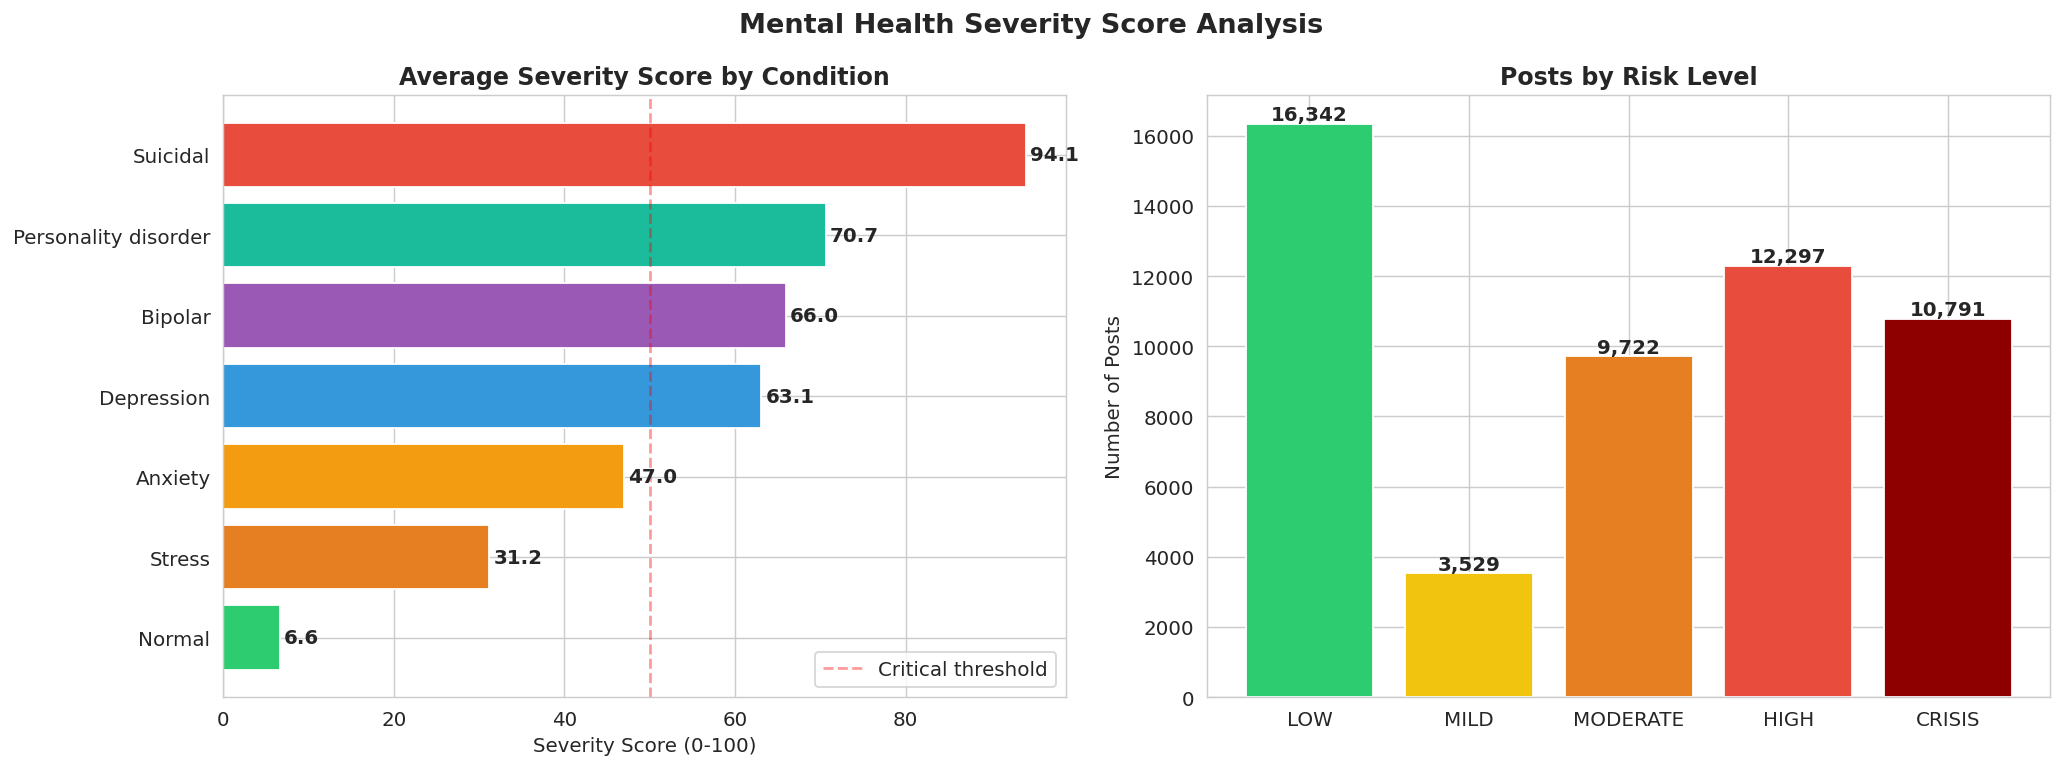

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Mental Health Severity Score Analysis',
             fontsize=15, fontweight='bold')

# Average severity per condition
avg_severity = df.groupby('label')['severity_score'].mean().sort_values()
colors_sev   = [PALETTE[l] for l in avg_severity.index]
bars = axes[0].barh(avg_severity.index, avg_severity.values,
                    color=colors_sev, edgecolor='white')
axes[0].set_title('Average Severity Score by Condition', fontweight='bold')
axes[0].set_xlabel('Severity Score (0-100)')
axes[0].axvline(50, color='red', linestyle='--', alpha=0.4, label='Critical threshold')
for bar, val in zip(bars, avg_severity.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontweight='bold')
axes[0].legend()

# Risk level distribution
risk_labels_map = []
for score in df['severity_score']:
    rl, _ = get_risk_level(score)
    risk_labels_map.append(rl.split()[-1])   # LOW / MILD / etc.

df['risk_cat'] = risk_labels_map
risk_order  = ['LOW','MILD','MODERATE','HIGH','CRISIS']
risk_colors = ['#2ECC71','#F1C40F','#E67E22','#E74C3C','#8E0000']
risk_counts = [df['risk_cat'].tolist().count(r) for r in risk_order]

bars2 = axes[1].bar(risk_order, risk_counts, color=risk_colors, edgecolor='white')
axes[1].set_title('Posts by Risk Level', fontweight='bold')
axes[1].set_ylabel('Number of Posts')
for bar, val in zip(bars2, risk_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100, f'{val:,}',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart9_severity_analysis.png', bbox_inches='tight')
plt.show()

**Summary**

In [47]:
best_row = results_df.iloc[0]
print()
print("=" * 65)
print("  🏁  PROJECT SUMMARY: MENTAL HEALTH AI ANALYSIS SYSTEM")
print("=" * 65)
print(f"  Dataset          : 52,681 real Reddit/social media posts")
print(f"  Conditions       : 7 (Normal, Depression, Anxiety, etc.)")
print(f"  Models Compared  : {len(models)}")
print(f"  Best Model       : {best_name}")
print(f"  Accuracy         : {best_row['Accuracy']*100:.2f}%")
print(f"  Weighted F1      : {best_row['Weighted F1']*100:.2f}%")
print(f"  Macro F1         : {best_row['Macro F1']*100:.2f}%")
print("=" * 65)
print()
print("  🔑 UNIQUE FEATURES OF THIS PROJECT:")
print("  1. ✅ 7-class mental health classification")
print("  2. ✅ 0-100 severity/risk scoring system")
print("  3. ✅ VADER + TextBlob dual sentiment engine")
print("  4. ✅ Trigger word & crisis signal detection")
print("  5. ✅ Personalized coping strategy recommender")
print("  6. ✅ Crisis alert with real Indian helpline numbers")
print("  7. ✅ 9 professional visualizations")
print("  8. ✅ 52,000+ real social media posts")
print("=" * 65)
print()
print("  📁 SAVED FILES:")
print("  - mental_health_model.pkl   (trained classifier)")
print("  - mental_health_tfidf.pkl   (TF-IDF vectorizer)")
print("  - mental_health_encoder.pkl (label encoder)")
print("  - chart1 to chart9          (all visualizations)")
print("=" * 65)


  🏁  PROJECT SUMMARY: MENTAL HEALTH AI ANALYSIS SYSTEM
  Dataset          : 52,681 real Reddit/social media posts
  Conditions       : 7 (Normal, Depression, Anxiety, etc.)
  Models Compared  : 5
  Best Model       : Linear SVM
  Accuracy         : 91.84%
  Weighted F1      : 91.89%
  Macro F1         : 83.56%

  🔑 UNIQUE FEATURES OF THIS PROJECT:
  1. ✅ 7-class mental health classification
  2. ✅ 0-100 severity/risk scoring system
  3. ✅ VADER + TextBlob dual sentiment engine
  4. ✅ Trigger word & crisis signal detection
  5. ✅ Personalized coping strategy recommender
  6. ✅ Crisis alert with real Indian helpline numbers
  7. ✅ 9 professional visualizations
  8. ✅ 52,000+ real social media posts

  📁 SAVED FILES:
  - mental_health_model.pkl   (trained classifier)
  - mental_health_tfidf.pkl   (TF-IDF vectorizer)
  - mental_health_encoder.pkl (label encoder)
  - chart1 to chart9          (all visualizations)
